In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torchvision
import warnings
import shutil

%matplotlib inline
warnings.filterwarnings("ignore")


In [2]:
image_cat = pd.read_csv("../input/train.csv", low_memory=False, index_col="id").to_dict()["has_cactus"]


In [3]:
??torchvision.datasets.ImageFolder


In [4]:
from torchvision.datasets import DatasetFolder, ImageFolder
from torchvision.datasets.folder import IMG_EXTENSIONS, default_loader

def make_dataset(dir, class_to_idx, extensions=None, is_valid_file=None):
    images = []
    dir = os.path.expanduser(dir)
    
    for filename in os.listdir(dir):
        path = os.path.join(dir, filename)
        item = (path, image_cat[filename])
        images.append(item)
    return images

class CactusImageFolder(DatasetFolder):
    def __init__(self, root, transform=None, target_transform=None, loader=default_loader, is_valid_file=None):                                                                                              
        self.root = root
        self.transform = transform
        self.target_transform = target_transform
        self.classes, self.class_to_idx = self._find_classes(self.root)
        self.samples = make_dataset(self.root, self.class_to_idx)
        self.loader = loader
        self.targets = [s[1] for s in self.samples]
        
    def _find_classes(self, dir):
        def f(x):
            return "cactus" if image_cat[x] == 1 else "noncactus"
        classes = list(set([ f(filename) for filename in os.listdir(dir)]))
        class_to_idx = {classes[i]: i for i in range(len(classes))}
        return classes, class_to_idx


In [5]:
from torchvision import transforms, datasets
data_transorm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = CactusImageFolder(root="../input/train/train", transform=data_transorm)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True, num_workers=4)

test_set = datasets.ImageFolder(root="../input/test", transform=data_transorm)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True, num_workers=4)

classes = train_set.classes


KeyError: 'train'

In [6]:
len(test_set)


NameError: name 'test_set' is not defined

In [7]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
data_iter = iter(train_loader)
images, labels = data_iter.next()
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))


NameError: name 'train_loader' is not defined

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
net = Net()


In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)


In [10]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')


NameError: name 'train_loader' is not defined

In [11]:
test_iter = iter(test_loader)
images, _ = test_iter.next()
images.name
imshow(torchvision.utils.make_grid(images))

outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))


NameError: name 'test_loader' is not defined

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
net.to(device)


cuda:0


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [13]:
preds = []

with torch.no_grad():
    for i, data in enumerate(test_loader):
        file_name = os.path.basename(test_set.imgs[i][0])
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        cactus = predicted[0].item()
        preds.append([file_name, cactus])


NameError: name 'test_loader' is not defined

In [14]:
!head ../input/sample_submission.csv


id,has_cactus
09034a34de0e2015a8a28dfe18f423f6.jpg,0.5
134f04305c795d6d202502c2ce3578f3.jpg,0.5
41fad8d145e6c41868ce3617e30a2545.jpg,0.5
35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.5
b77dc902b035887cbbc01920ce0e3151.jpg,0.5
33baa477c94f9171566f52c4a8f53ec8.jpg,0.5
bc6f04ed633c3e3e52125f9b6c078bf3.jpg,0.5
9f988c7fcb21f35f523b0faecc590cb7.jpg,0.5
ca3a10b0f34219a40f6d6d5a2d863826.jpg,0.5


In [15]:
output = pd.DataFrame(preds, columns=["id", "has_cactus"])
output.to_csv("submission.csv", index=False)


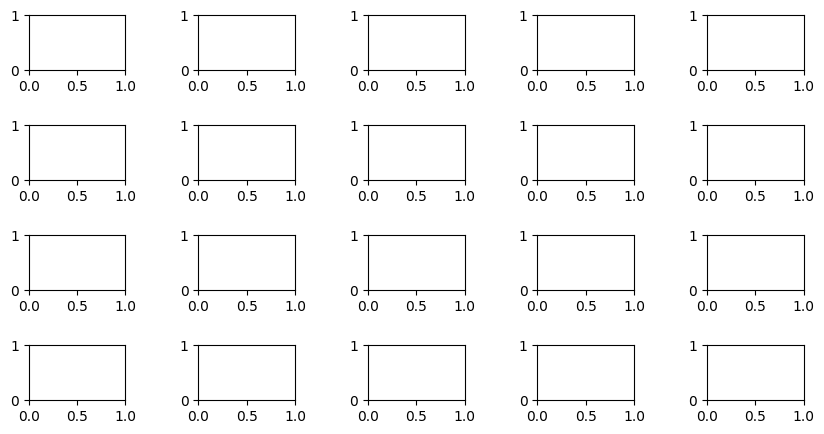

In [16]:
rows, cols = 4, 5
i = 0
fig, ax = plt.subplots(nrows=rows, ncols=cols, squeeze=False, figsize=(10, 5))
fig.subplots_adjust(hspace=1.0, wspace=0.75)
for name, label in output.iloc[:20].values:    
    img = plt.imread(f"../input/test/test/{name}")
    row = int(i/cols)
    col = i%cols
    ax[row][col].imshow(img)
    ax[row][col].title.set_text(f"Cactus? {label == 1}")
    i += 1
